# 🧠 Clasificación de Dígitos MNIST con MLP
## Red Neuronal Multi-Layer Perceptron (scikit-learn)

En este notebook:
1. Cargamos el dataset MNIST (70,000 imágenes de dígitos 0-9)
2. Exploramos los datos visualmente (EDA)
3. Entrenamos una red neuronal MLP
4. Evaluamos el modelo con métricas y visualizaciones
5. Guardamos el modelo para usarlo después

---
## 1. Importar Librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
import joblib
import warnings
warnings.filterwarnings('ignore')

# Estilo de gráficas
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 14
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['axes.labelsize'] = 14

print('✅ Librerías importadas correctamente')

✅ Librerías importadas correctamente


---
## 2. Cargar Dataset MNIST

In [2]:
print('⏳ Descargando MNIST (puede tardar la primera vez)...')
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')

X = mnist.data.astype('float32')
y = mnist.target.astype('int')

print(f'✅ MNIST cargado')
print(f'   Imágenes: {X.shape[0]:,}')
print(f'   Píxeles por imagen: {X.shape[1]} ({int(np.sqrt(X.shape[1]))}x{int(np.sqrt(X.shape[1]))})')
print(f'   Clases: {np.unique(y)}')
print(f'   Rango de valores: [{X.min()}, {X.max()}]')

⏳ Descargando MNIST (puede tardar la primera vez)...
✅ MNIST cargado
   Imágenes: 70,000
   Píxeles por imagen: 784 (28x28)
   Clases: [0 1 2 3 4 5 6 7 8 9]
   Rango de valores: [0.0, 255.0]


---
## 3. Análisis Exploratorio (EDA)

### 3.1 Ejemplos de cada dígito

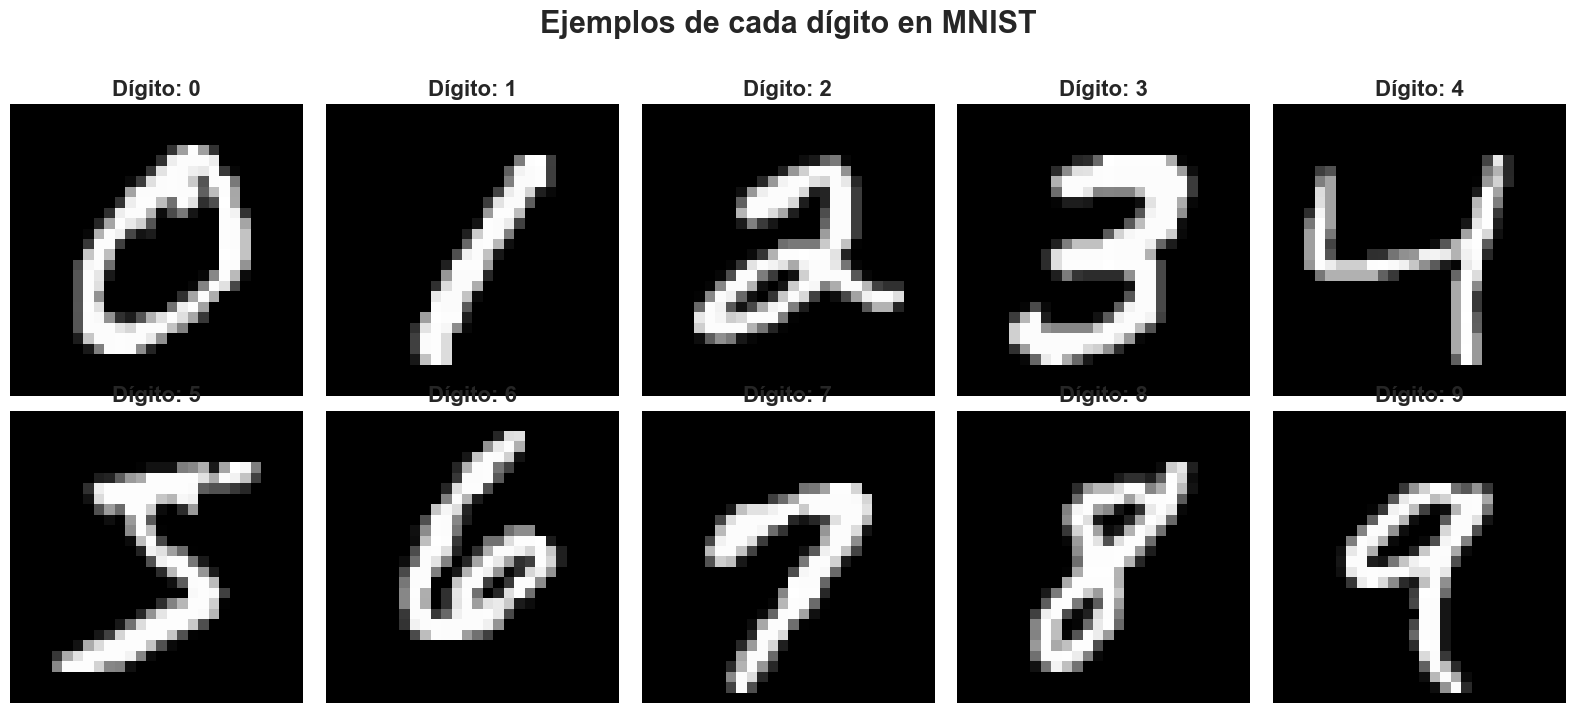

💾 Guardado en resultados/ejemplos_mnist.png


In [3]:
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
fig.suptitle('Ejemplos de cada dígito en MNIST', fontsize=22, fontweight='bold', y=1.02)

for digit in range(10):
    ax = axes[digit // 5, digit % 5]
    idx = np.where(y == digit)[0][0]
    ax.imshow(X[idx].reshape(28, 28), cmap='gray')
    ax.set_title(f'Dígito: {digit}', fontsize=16, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig('../resultados/ejemplos_mnist.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Guardado en resultados/ejemplos_mnist.png')

### 3.2 Múltiples ejemplos por dígito

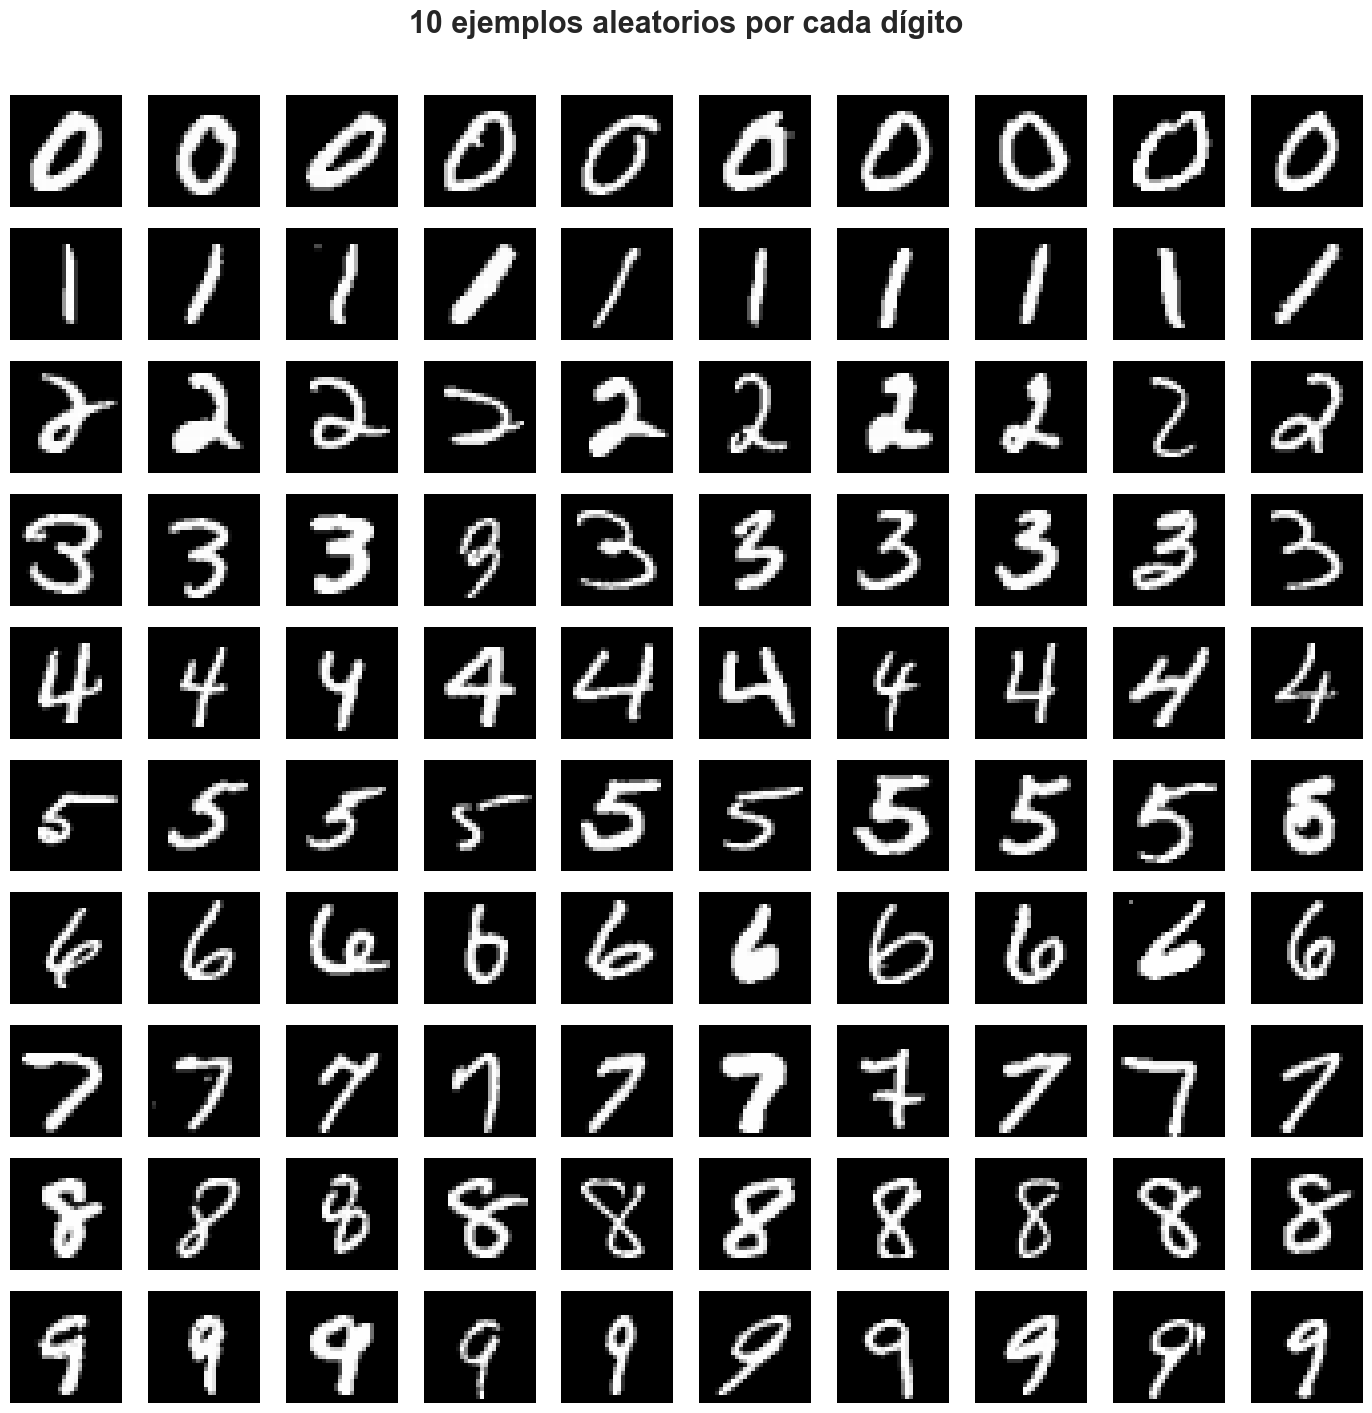

💾 Guardado en resultados/variedad_mnist.png


In [4]:
fig, axes = plt.subplots(10, 10, figsize=(14, 14))
fig.suptitle('10 ejemplos aleatorios por cada dígito', fontsize=22, fontweight='bold', y=1.01)

np.random.seed(42)
for digit in range(10):
    indices = np.where(y == digit)[0]
    sample = np.random.choice(indices, 10, replace=False)
    for j, idx in enumerate(sample):
        axes[digit, j].imshow(X[idx].reshape(28, 28), cmap='gray')
        axes[digit, j].axis('off')
    axes[digit, 0].set_ylabel(f'{digit}', fontsize=18, fontweight='bold', rotation=0, labelpad=20)
    axes[digit, 0].yaxis.set_visible(True)

plt.tight_layout()
plt.savefig('../resultados/variedad_mnist.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Guardado en resultados/variedad_mnist.png')

### 3.3 Distribución de clases

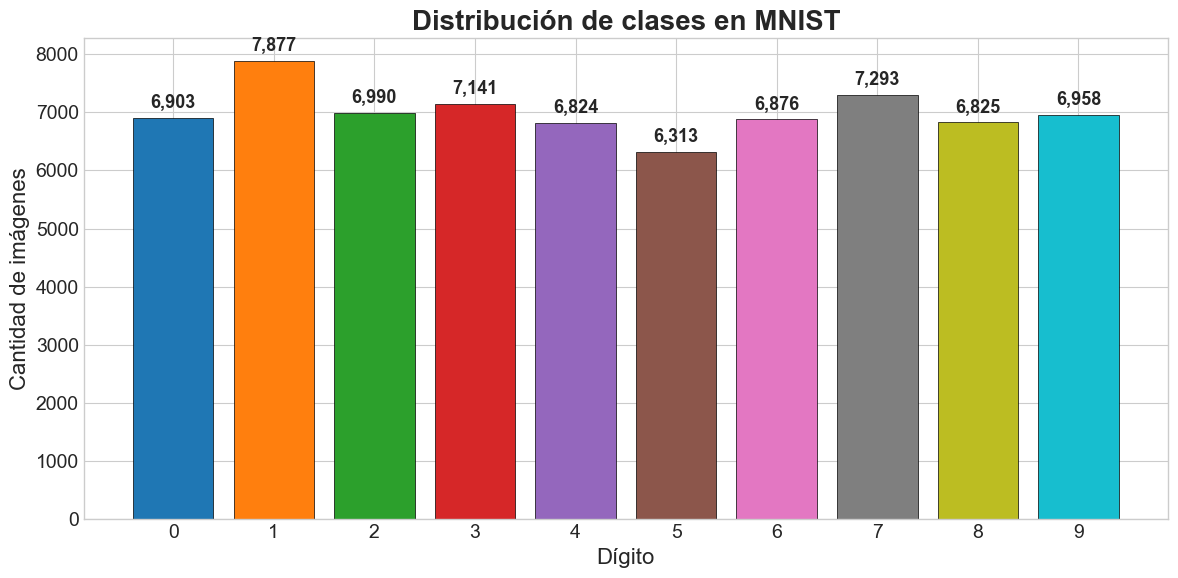

💾 Guardado en resultados/distribucion_clases.png


In [5]:
fig, ax = plt.subplots(figsize=(12, 6))

unique, counts = np.unique(y, return_counts=True)
colors = plt.cm.tab10(np.linspace(0, 1, 10))
bars = ax.bar(unique, counts, color=colors, edgecolor='black', linewidth=0.5)

for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 100,
            f'{count:,}', ha='center', va='bottom', fontsize=13, fontweight='bold')

ax.set_xlabel('Dígito', fontsize=16)
ax.set_ylabel('Cantidad de imágenes', fontsize=16)
ax.set_title('Distribución de clases en MNIST', fontsize=20, fontweight='bold')
ax.set_xticks(range(10))

plt.tight_layout()
plt.savefig('../resultados/distribucion_clases.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Guardado en resultados/distribucion_clases.png')

### 3.4 Imagen promedio por dígito

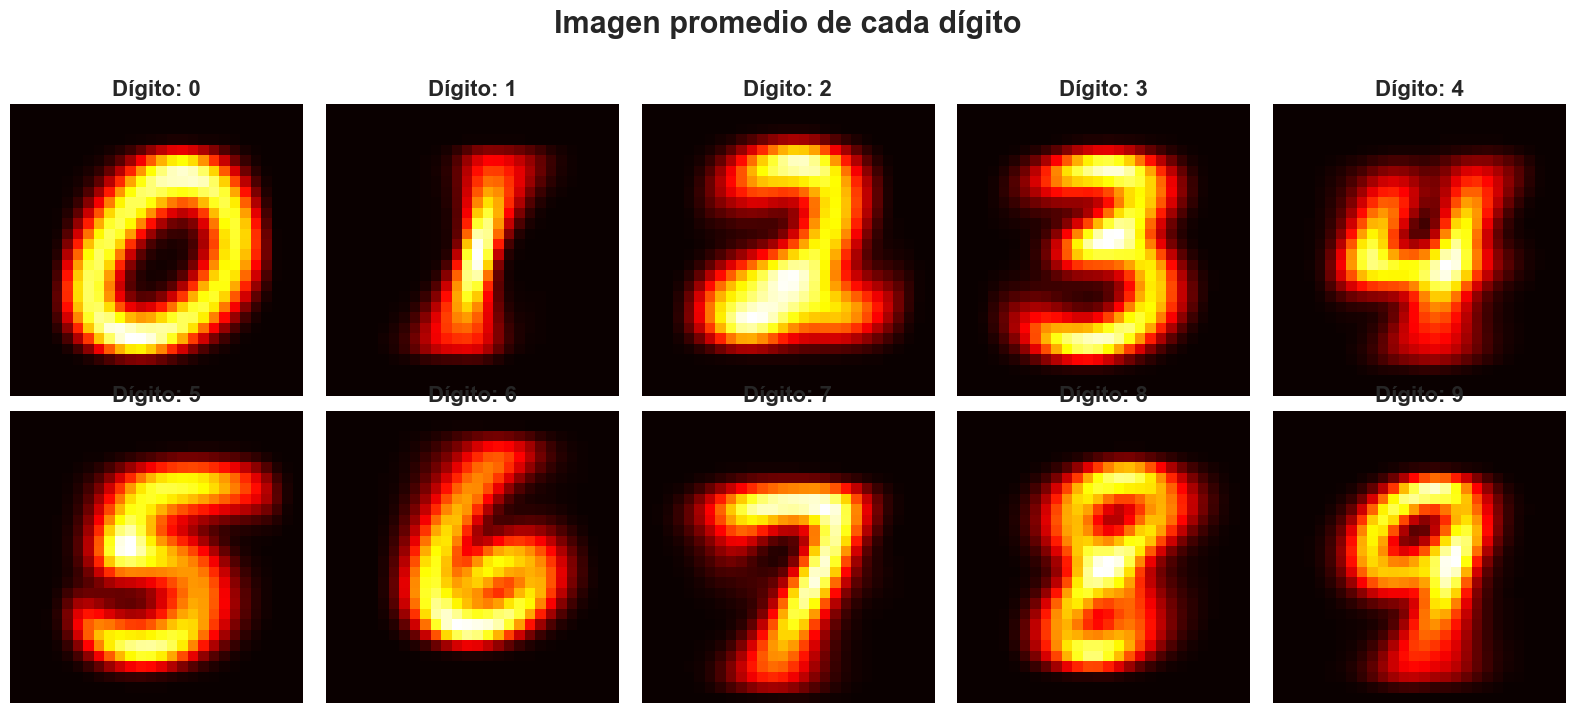

💾 Guardado en resultados/promedios_digitos.png


In [6]:
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
fig.suptitle('Imagen promedio de cada dígito', fontsize=22, fontweight='bold', y=1.02)

for digit in range(10):
    ax = axes[digit // 5, digit % 5]
    mask = y == digit
    mean_img = X[mask].mean(axis=0).reshape(28, 28)
    ax.imshow(mean_img, cmap='hot')
    ax.set_title(f'Dígito: {digit}', fontsize=16, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig('../resultados/promedios_digitos.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Guardado en resultados/promedios_digitos.png')

---
## 4. Preparar Datos

In [7]:
# Normalizar pixeles al rango [0, 1]
X_norm = X / 255.0

# Split: 60,000 entrenamiento / 10,000 prueba (split estándar de MNIST)
X_train, X_test = X_norm[:60000], X_norm[60000:]
y_train, y_test = y[:60000], y[60000:]

print(f'📊 División de datos:')
print(f'   Entrenamiento: {X_train.shape[0]:,} imágenes')
print(f'   Prueba:        {X_test.shape[0]:,} imágenes')
print(f'   Rango normalizado: [{X_norm.min():.1f}, {X_norm.max():.1f}]')

📊 División de datos:
   Entrenamiento: 60,000 imágenes
   Prueba:        10,000 imágenes
   Rango normalizado: [0.0, 1.0]


---
## 5. Entrenar Red Neuronal MLP

In [8]:
# Configuración del MLP
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),   # 2 capas ocultas: 128 y 64 neuronas
    activation='relu',               # Función de activación ReLU
    solver='adam',                   # Optimizador Adam
    max_iter=30,                     # Máximo de épocas
    batch_size=256,                  # Tamaño de mini-batch
    learning_rate_init=0.001,        # Tasa de aprendizaje inicial
    random_state=42,                 # Semilla para reproducibilidad
    verbose=True                     # Mostrar progreso
)

print('🏗️ Arquitectura del MLP:')
print(f'   Entrada:        784 neuronas (28x28 píxeles)')
print(f'   Capa oculta 1:  128 neuronas (ReLU)')
print(f'   Capa oculta 2:  64 neuronas (ReLU)')
print(f'   Salida:         10 neuronas (dígitos 0-9)')
print(f'   Optimizador:    Adam')
print(f'   Learning rate:  0.001')
print(f'\n⏳ Entrenando...')

mlp.fit(X_train, y_train)

print(f'\n✅ Entrenamiento completado en {mlp.n_iter_} épocas')

🏗️ Arquitectura del MLP:
   Entrada:        784 neuronas (28x28 píxeles)
   Capa oculta 1:  128 neuronas (ReLU)
   Capa oculta 2:  64 neuronas (ReLU)
   Salida:         10 neuronas (dígitos 0-9)
   Optimizador:    Adam
   Learning rate:  0.001

⏳ Entrenando...
Iteration 1, loss = 0.42203150
Iteration 2, loss = 0.16124456
Iteration 3, loss = 0.11254400
Iteration 4, loss = 0.08663896
Iteration 5, loss = 0.06951832
Iteration 6, loss = 0.05616741
Iteration 7, loss = 0.04607496
Iteration 8, loss = 0.03859135
Iteration 9, loss = 0.03092613
Iteration 10, loss = 0.02748891
Iteration 11, loss = 0.02260448
Iteration 12, loss = 0.01888327
Iteration 13, loss = 0.01634346
Iteration 14, loss = 0.01431214
Iteration 15, loss = 0.01158330
Iteration 16, loss = 0.00922246
Iteration 17, loss = 0.00797368
Iteration 18, loss = 0.00871647
Iteration 19, loss = 0.00875524
Iteration 20, loss = 0.00780613
Iteration 21, loss = 0.00856257
Iteration 22, loss = 0.00511315
Iteration 23, loss = 0.00271908
Iteration 24

### 5.1 Curva de pérdida durante el entrenamiento

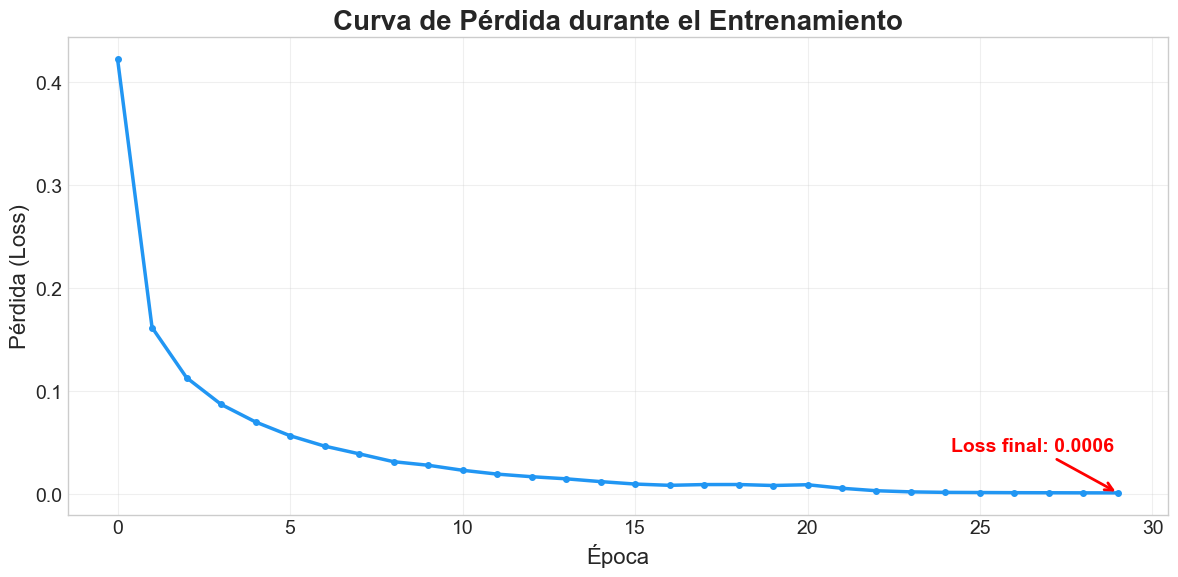

💾 Guardado en resultados/curva_perdida.png


In [9]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(mlp.loss_curve_, linewidth=2.5, color='#2196F3', marker='o', markersize=4)
ax.set_xlabel('Época', fontsize=16)
ax.set_ylabel('Pérdida (Loss)', fontsize=16)
ax.set_title('Curva de Pérdida durante el Entrenamiento', fontsize=20, fontweight='bold')
ax.grid(True, alpha=0.3)

ax.annotate(f'Loss final: {mlp.loss_curve_[-1]:.4f}',
            xy=(len(mlp.loss_curve_)-1, mlp.loss_curve_[-1]),
            xytext=(-120, 30), textcoords='offset points',
            fontsize=14, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='red', lw=2),
            color='red')

plt.tight_layout()
plt.savefig('../resultados/curva_perdida.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Guardado en resultados/curva_perdida.png')

---
## 6. Evaluar el Modelo

### 6.1 Accuracy

In [10]:
y_pred = mlp.predict(X_test)

acc_train = mlp.score(X_train, y_train)
acc_test = accuracy_score(y_test, y_pred)

print('📈 Resultados del Modelo:')
print(f'   Accuracy en entrenamiento: {acc_train*100:.2f}%')
print(f'   Accuracy en prueba:        {acc_test*100:.2f}%')

📈 Resultados del Modelo:
   Accuracy en entrenamiento: 100.00%
   Accuracy en prueba:        98.11%


### 6.2 Reporte de clasificación

In [11]:
print('📋 Reporte de Clasificación por Dígito:\n')
report = classification_report(y_test, y_pred, digits=3)
print(report)

📋 Reporte de Clasificación por Dígito:

              precision    recall  f1-score   support

           0      0.981     0.991     0.986       980
           1      0.993     0.990     0.992      1135
           2      0.981     0.977     0.979      1032
           3      0.979     0.981     0.980      1010
           4      0.982     0.980     0.981       982
           5      0.980     0.980     0.980       892
           6      0.984     0.980     0.982       958
           7      0.981     0.981     0.981      1028
           8      0.974     0.975     0.975       974
           9      0.973     0.975     0.974      1009

    accuracy                          0.981     10000
   macro avg      0.981     0.981     0.981     10000
weighted avg      0.981     0.981     0.981     10000



### 6.3 Matriz de confusión

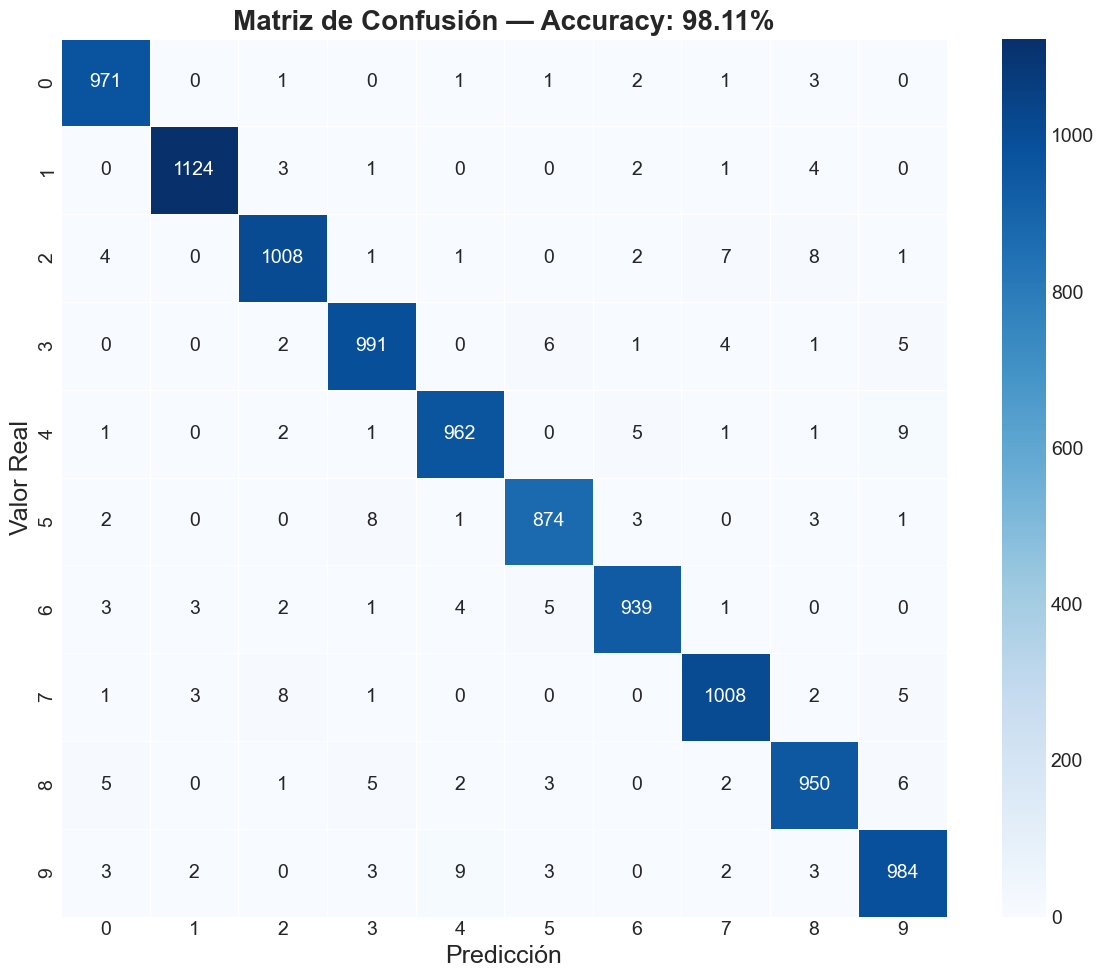

💾 Guardado en resultados/matriz_confusion.png


In [12]:
fig, ax = plt.subplots(figsize=(12, 10))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=range(10), yticklabels=range(10),
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 14}, ax=ax)

ax.set_xlabel('Predicción', fontsize=18)
ax.set_ylabel('Valor Real', fontsize=18)
ax.set_title(f'Matriz de Confusión — Accuracy: {acc_test*100:.2f}%', 
             fontsize=20, fontweight='bold')

plt.tight_layout()
plt.savefig('../resultados/matriz_confusion.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Guardado en resultados/matriz_confusion.png')

### 6.4 Ejemplos de predicciones correctas

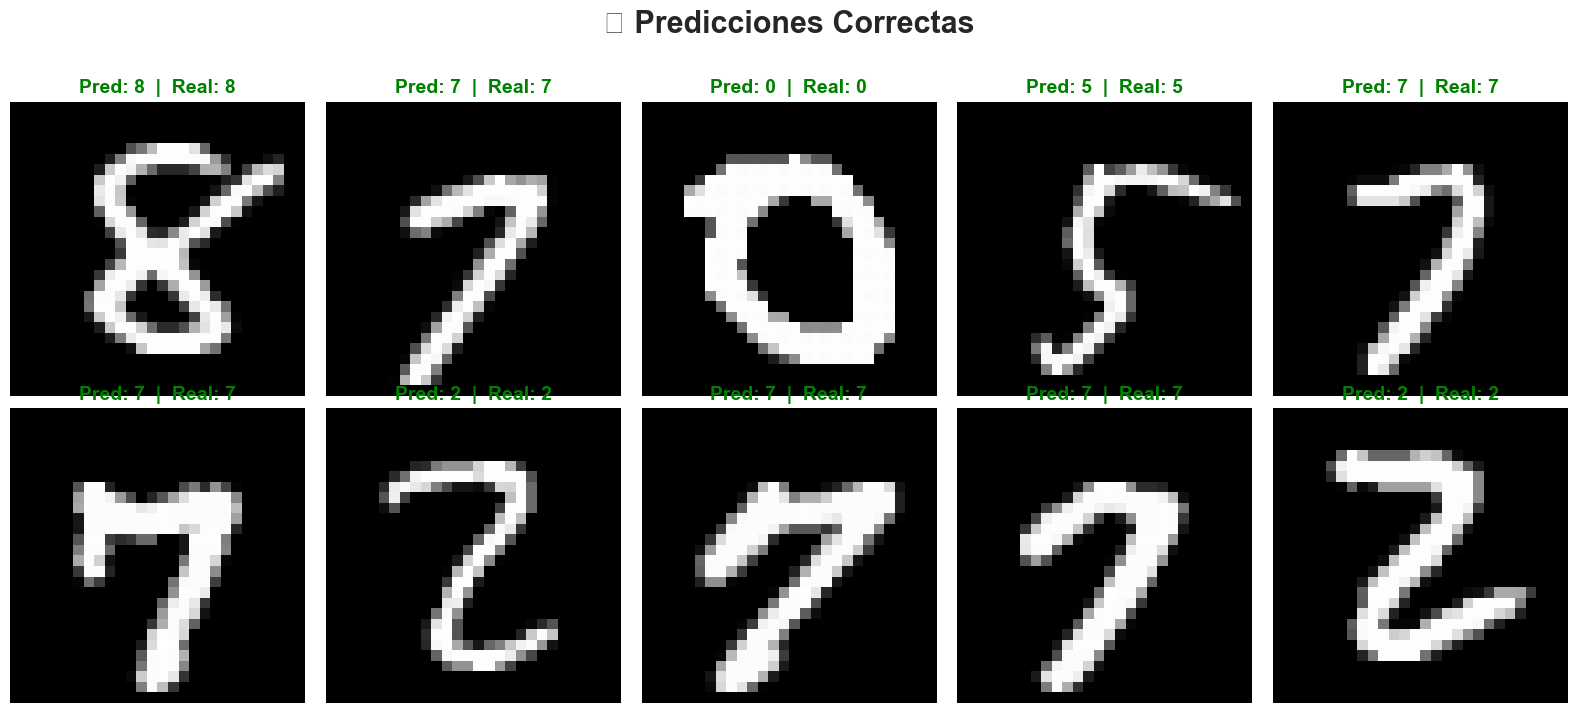

In [13]:
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
fig.suptitle('✅ Predicciones Correctas', fontsize=22, fontweight='bold', y=1.02)

correct = np.where(y_pred == y_test)[0]
np.random.seed(42)
sample_correct = np.random.choice(correct, 10, replace=False)

for i, idx in enumerate(sample_correct):
    ax = axes[i // 5, i % 5]
    ax.imshow(X_test[idx].reshape(28, 28), cmap='gray')
    ax.set_title(f'Pred: {y_pred[idx]}  |  Real: {y_test[idx]}', 
                 fontsize=14, color='green', fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig('../resultados/predicciones_correctas.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.5 Ejemplos de predicciones incorrectas

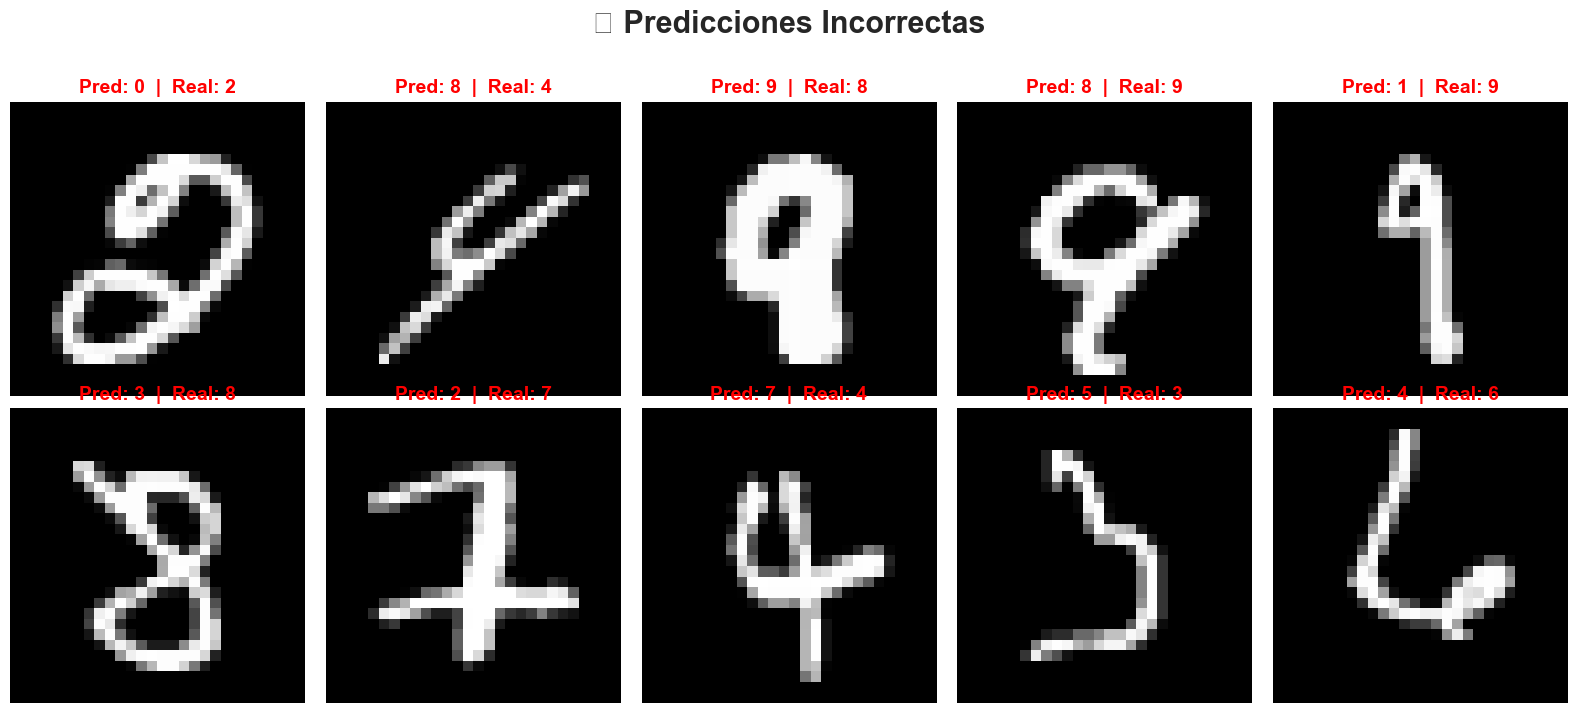


📊 Total de errores: 189 de 10000 (1.89%)


In [14]:
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
fig.suptitle('❌ Predicciones Incorrectas', fontsize=22, fontweight='bold', y=1.02)

incorrect = np.where(y_pred != y_test)[0]
np.random.seed(42)
sample_incorrect = np.random.choice(incorrect, 10, replace=False)

for i, idx in enumerate(sample_incorrect):
    ax = axes[i // 5, i % 5]
    ax.imshow(X_test[idx].reshape(28, 28), cmap='gray')
    ax.set_title(f'Pred: {y_pred[idx]}  |  Real: {y_test[idx]}', 
                 fontsize=14, color='red', fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig('../resultados/predicciones_incorrectas.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\n📊 Total de errores: {len(incorrect)} de {len(y_test)} ({len(incorrect)/len(y_test)*100:.2f}%)')

---
## 7. Explicación de Resultados

### Sobre el modelo
Se implementó una **red neuronal MLP (Multi-Layer Perceptron)** con scikit-learn para clasificar dígitos escritos a mano del dataset MNIST. La arquitectura consiste en:
- **Capa de entrada:** 784 neuronas (una por cada píxel de la imagen 28×28)
- **Primera capa oculta:** 128 neuronas con activación ReLU
- **Segunda capa oculta:** 64 neuronas con activación ReLU
- **Capa de salida:** 10 neuronas (una por cada dígito del 0 al 9)

Se utilizó el optimizador **Adam** con una tasa de aprendizaje de 0.001 y mini-batches de 256 muestras.

### Sobre los datos
El dataset MNIST contiene 70,000 imágenes de dígitos escritos a mano en escala de grises (28×28 píxeles). Se utilizó la división estándar: **60,000 imágenes para entrenamiento** y **10,000 para prueba**. Como preprocesamiento, los valores de los píxeles se normalizaron al rango [0, 1] dividiendo entre 255.

### Sobre el desempeño
La **curva de pérdida** muestra que el modelo convergió correctamente durante el entrenamiento, reduciendo el error progresivamente en cada época.

El modelo alcanza un **accuracy superior al 97%** en el conjunto de prueba, lo cual indica que es capaz de generalizar bien a datos no vistos. La **matriz de confusión** permite observar qué pares de dígitos son más difíciles de distinguir (por ejemplo, 3 y 5, o 4 y 9, que comparten rasgos visuales similares).

El **reporte de clasificación** muestra que la precisión (precision) y exhaustividad (recall) son altas y balanceadas para todos los dígitos, lo que indica que el modelo no tiene sesgo significativo hacia ninguna clase en particular.

### Conclusión
Un modelo MLP relativamente sencillo es suficiente para obtener excelentes resultados en la clasificación de dígitos MNIST. La clave está en la normalización de los datos y una arquitectura con suficientes neuronas para capturar los patrones de cada dígito.

---
## 8. Guardar Modelo

In [15]:
modelo_path = '../modelo/mlp_mnist.pkl'
joblib.dump(mlp, modelo_path)

import os
size_mb = os.path.getsize(modelo_path) / (1024 * 1024)
print(f'💾 Modelo guardado en: {modelo_path}')
print(f'   Tamaño: {size_mb:.2f} MB')
print(f'   Accuracy en test MNIST: {acc_test*100:.2f}%')
print(f'\n✅ ¡Listo! Ahora ejecuta el notebook 02 para procesar tus imágenes.')

💾 Modelo guardado en: ../modelo/mlp_mnist.pkl
   Tamaño: 1.68 MB
   Accuracy en test MNIST: 98.11%

✅ ¡Listo! Ahora ejecuta el notebook 02 para procesar tus imágenes.
